# EDA Sample:

In [1]:
import pandas as pd

df = pd.read_parquet("merged_sample_one_processed/final_stage/part.0.parquet")
print(f"Shape: {df.shape}")

Shape: (1213641, 71)


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1213641 entries, 0 to 1213640
Data columns (total 71 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   anon_id                  1213641 non-null  string 
 1   pat_enc_csn_id_coded     1213641 non-null  int64  
 2   order_proc_id_coded      1213641 non-null  int64  
 3   order_time_jittered_utc  1213641 non-null  string 
 4   organism                 1213641 non-null  int8   
 5   antibiotic               1213641 non-null  int8   
 6   susceptibility           1213641 non-null  Int8   
 7   med_within_30_days       1131261 non-null  boolean
 8   n_med_categories         1131261 non-null  float64
 9   min_time_to_med          1131261 non-null  Int32  
 10  age                      1213641 non-null  Int8   
 11  gender                   1213641 non-null  Int8   
 12  Period_Day               1152187 non-null  Int64  
 13  Q25_wbc                  1142011 non-null  float32
 1

In [3]:
print(df['susceptibility'].value_counts())

susceptibility
0    827853
1    385788
Name: count, dtype: Int64


0 => Susceptible
1 => Resistant


Susceptibility distribution saved to figs/susceptibility_distribution.png


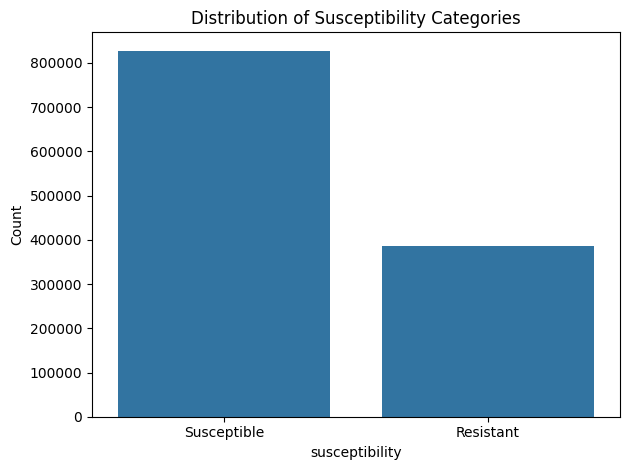

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig_dir = "figs"

sns.countplot(x='susceptibility', data=df)
plt.title("Distribution of Susceptibility Categories")
plt.ylabel("Count")
plt.xticks(ticks=[0, 1], labels=["Susceptible", "Resistant"])  # Change tick labels only
plt.tight_layout()
plt.savefig(f"{fig_dir}/susceptibility_distribution.png")
print(f"Susceptibility distribution saved to {fig_dir}/susceptibility_distribution.png")
plt.show()

## Correlation Heatmap

In [5]:
# Explicitly drop key columns
cols_to_drop = [
    "anon_id",
    "pat_enc_csn_id_coded",
    "order_proc_id_coded",
    "order_time_jittered_utc"
]

X_numeric = df.drop(columns=cols_to_drop, errors="ignore")

Correlation heatmap saved to figs/correlation_heatmap.png


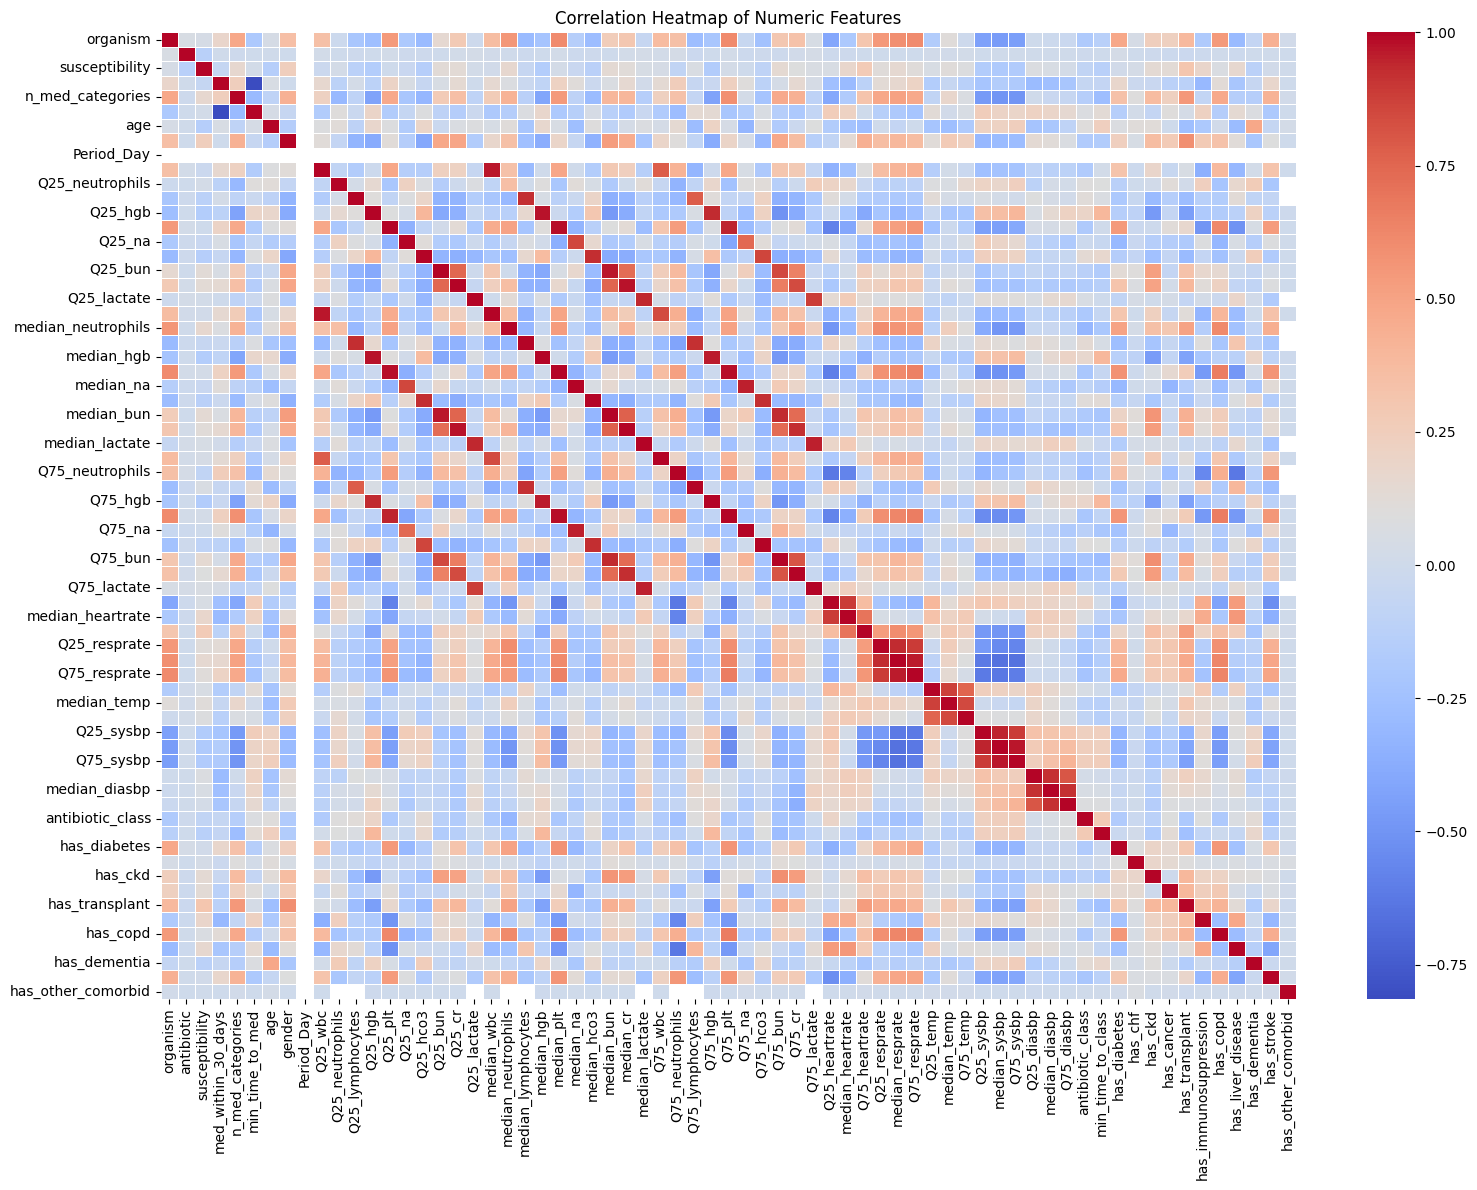

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fig_dir = "figs"

df_corr = X_numeric.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(df_corr, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig(f"{fig_dir}/correlation_heatmap.png", dpi=300)
print(f"Correlation heatmap saved to {fig_dir}/correlation_heatmap.png")
plt.show()


# Age and Gender Distribution (Pre-Merging Dataset)

<class 'pandas.DataFrame'>
RangeIndex: 4875 entries, 0 to 4874
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   anon_id               4875 non-null   str  
 1   pat_enc_csn_id_coded  4875 non-null   int64
 2   order_proc_id_coded   4875 non-null   int64
 3   age                   4875 non-null   Int8 
 4   gender                4875 non-null   Int8 
dtypes: Int8(2), int64(2), str(1)
memory usage: 174.4 KB
gender
Female    3285
Male      1590
Name: count, dtype: int64
Using all records for demographic analysis.
Age distribution plot saved: figs\age_distribution_patients.png


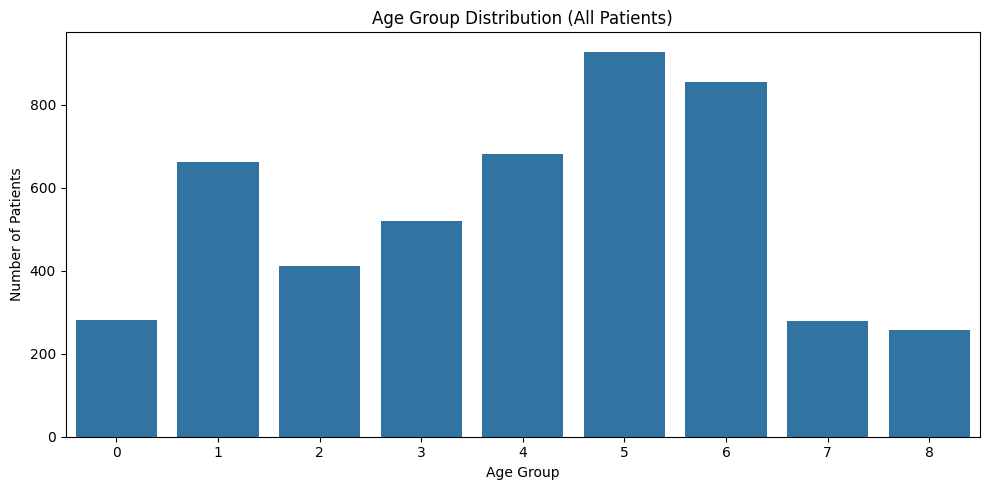

Gender distribution plot saved: figs\gender_distribution_patients.png


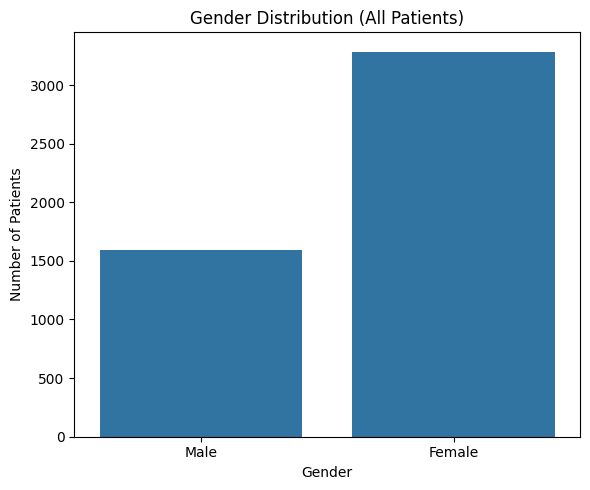

Age by gender plot saved: figs\age_by_gender_patients.png


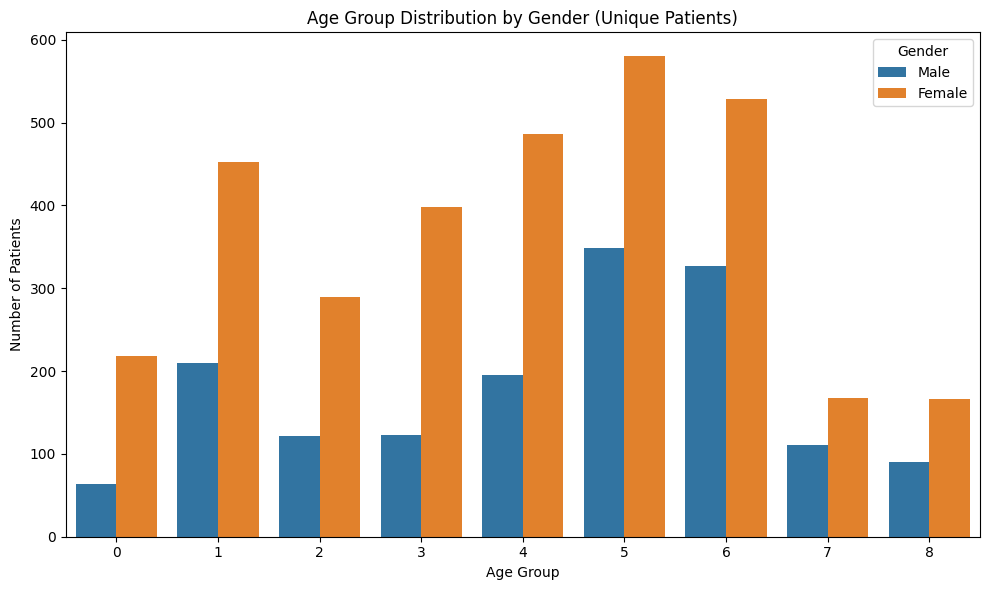

In [11]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_parquet("new_sample_one_processed/processed_cultures_demographics.parquet")
df.info()

df['gender'] = df['gender'].map({0: "Female", 1: "Male"})
print(df['gender'].value_counts())

# Create figure directory
fig_dir = "figs"
os.makedirs(fig_dir, exist_ok=True)


unique = False
if unique:
    df = df.drop_duplicates(subset="anon_id").copy()
    print("Using unique patients for demographic analysis.")
else:
    print("Using all records for demographic analysis.")

# -------------------------
# 1) Age distribution
# -------------------------
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='age',
    order=sorted(df['age'].unique())
)
plt.title(f"Age Group Distribution ({'Unique' if unique else 'All'} Patients)")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.tight_layout()

filename = f"age_distribution_{'' if not unique else 'unique_'}patients.png"

plt.savefig(os.path.join(fig_dir,filename) , dpi=300)
print(f"Age distribution plot saved: {os.path.join(fig_dir, filename)}")
plt.show()

# -------------------------
# 2) Gender distribution
# -------------------------
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='gender')
plt.title(f"Gender Distribution ({'Unique' if unique else 'All'} Patients)")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.tight_layout()

filename = f"gender_distribution_{'' if not unique else 'unique_'}patients.png"
plt.savefig(os.path.join(fig_dir, filename), dpi=300)
print(f"Gender distribution plot saved: {os.path.join(fig_dir, filename)}")
plt.show()

# -------------------------
# 3) Age by Gender
# -------------------------
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='age',
    hue='gender',
    order=sorted(df['age'].unique())
)
plt.title("Age Group Distribution by Gender (Unique Patients)")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.legend(title="Gender")
plt.tight_layout()

plt.savefig(os.path.join(fig_dir, f"age_by_gender_{'' if not unique else 'unique_'}patients.png"), dpi=300)

filename = f"age_by_gender_{'' if not unique else 'unique_'}patients.png"
filepath = os.path.join(fig_dir, filename)

plt.savefig(filepath, dpi=300)
print(f"Age by gender plot saved: {filepath}")
plt.show()

# Age and Gender Distribution (Post-Merging Dataset)

gender
Male      669119
Female    544522
Name: count, dtype: int64
age
18-24 years      7951
25-34 years     40158
35-44 years     44695
45-54 years    284681
55-64 years    382186
65-74 years    164426
75-84 years    153398
85-89 years     52914
above 90        83232
Name: count, dtype: int64
Using all records for demographic analysis.
Age distribution plot saved: figs\age_distribution_patients_post_merging.png


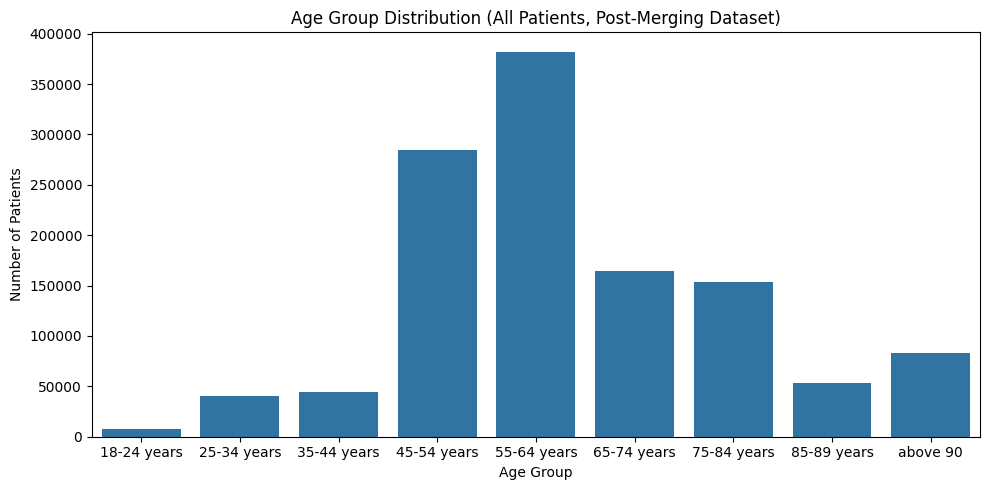

Gender distribution plot saved: figs\gender_distribution_patients_post_merging.png


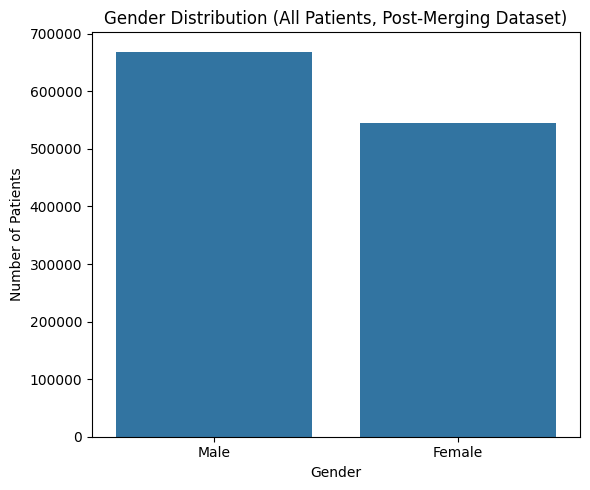

Age by gender plot saved: figs\age_by_gender_patients_post_merging.png


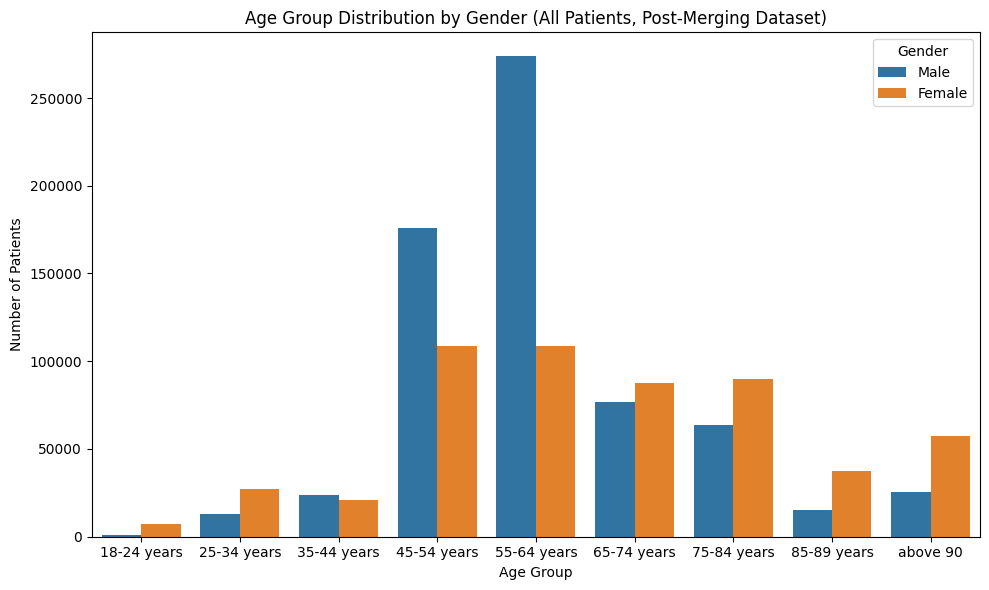

In [8]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df = pd.read_parquet("merged_sample_one_processed/final_stage/part.0.parquet")

# Convert gender safely (in case stored as string)
df['gender'] = df['gender'].map({'0': "Female", '1': "Male", 0: "Female", 1: "Male"})
print(df['gender'].value_counts())

age = {
    0: "18-24 years",
    1: "25-34 years",
    2: "35-44 years",
    3: "45-54 years",
    4: "55-64 years",
    5: "65-74 years",
    6: "75-84 years",
    7: "85-89 years",
    8: "above 90",
}
df['age'] = df['age'].map(age)
print(df['age'].value_counts().sort_index())

# Create figure directory
fig_dir = "figs"
os.makedirs(fig_dir, exist_ok=True)

unique = False

if unique:
    df = df.drop_duplicates(subset="anon_id").copy()
    print("Using unique patients for demographic analysis.")
else:
    print("Using all records for demographic analysis.")

# Dynamic labels
patient_type = "Unique" if unique else "All"
suffix = "unique_" if unique else ""
stage_label = "Post-Merging Dataset"

# -------------------------
# 1) Age distribution
# -------------------------
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='age',
    order=sorted(df['age'].dropna().unique())
)

plt.title(f"Age Group Distribution ({patient_type} Patients, {stage_label})")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.tight_layout()

filename = f"age_distribution_{suffix}patients_post_merging.png"
filepath = os.path.join(fig_dir, filename)

plt.savefig(filepath, dpi=300)
print(f"Age distribution plot saved: {filepath}")
plt.show()


# -------------------------
# 2) Gender distribution
# -------------------------
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x='gender')

plt.title(f"Gender Distribution ({patient_type} Patients, {stage_label})")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.tight_layout()

filename = f"gender_distribution_{suffix}patients_post_merging.png"
filepath = os.path.join(fig_dir, filename)

plt.savefig(filepath, dpi=300)
print(f"Gender distribution plot saved: {filepath}")
plt.show()


# -------------------------
# 3) Age by Gender
# -------------------------
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    x='age',
    hue='gender',
    order=sorted(df['age'].dropna().unique())
)

plt.title(f"Age Group Distribution by Gender ({patient_type} Patients, {stage_label})")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")
plt.legend(title="Gender")
plt.tight_layout()

filename = f"age_by_gender_{suffix}patients_post_merging.png"
filepath = os.path.join(fig_dir, filename)

plt.savefig(filepath, dpi=300)
print(f"Age by gender plot saved: {filepath}")
plt.show()

Pivot table shape: (20, 29)
Heatmap saved: figs\organism_antibiotic_heatmap_post_merging.png


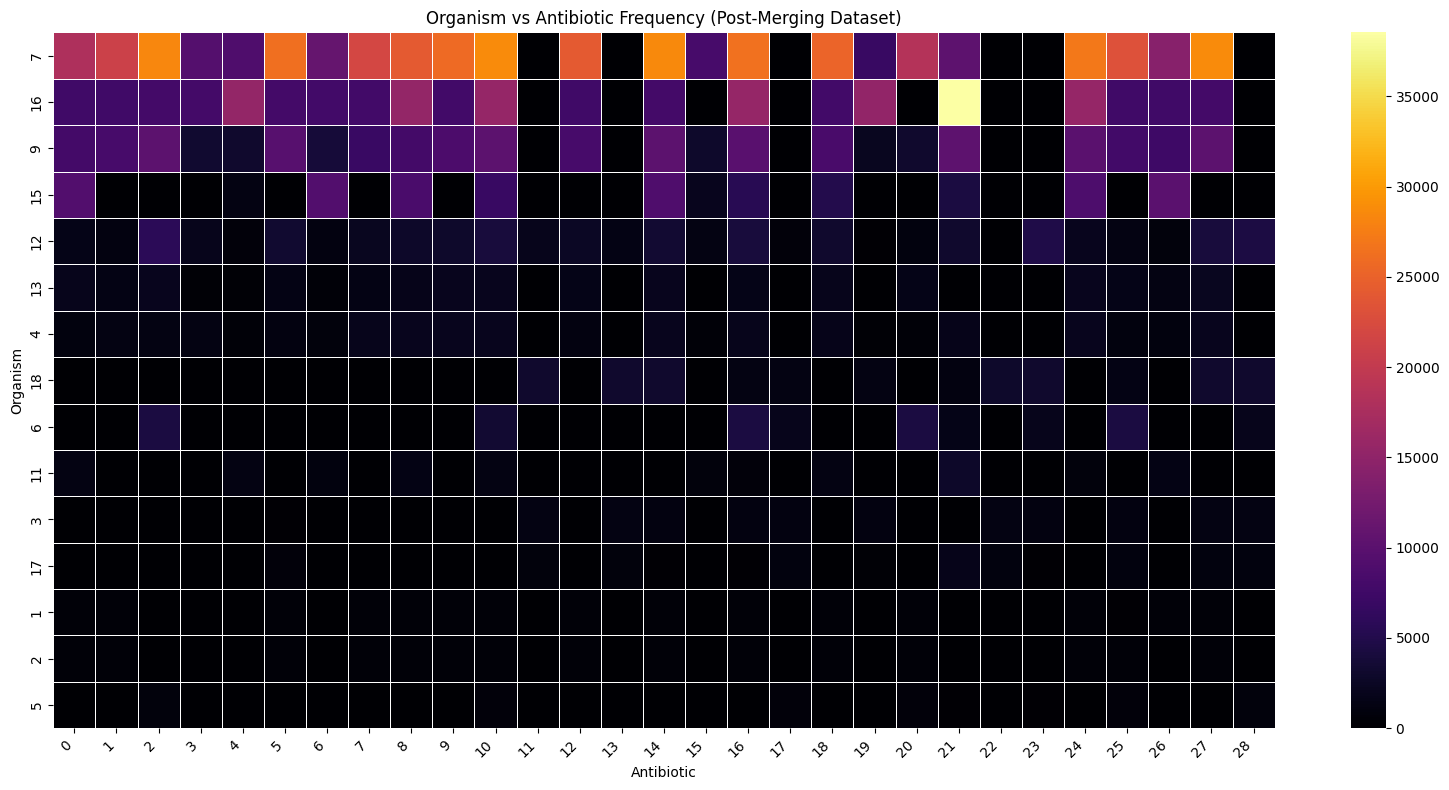

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_parquet("merged_sample_one_processed/final_stage/part.0.parquet")

# Create figure directory
fig_dir = "figs"
os.makedirs(fig_dir, exist_ok=True)

# -------------------------
# 1) Create pivot table
# -------------------------
heatmap_data = pd.crosstab(df['organism'], df['antibiotic'])

print("Pivot table shape:", heatmap_data.shape)

# Optional: reduce to top N organisms for readability
top_n = 15
top_organisms = df['organism'].value_counts().head(top_n).index
heatmap_data = heatmap_data.loc[top_organisms]

# -------------------------
# 2) Plot Heatmap
# -------------------------
plt.figure(figsize=(16, 8))

sns.heatmap(heatmap_data, cmap="inferno", linewidths=0.5)

plt.title("Organism vs Antibiotic Frequency (Post-Merging Dataset)")
plt.xlabel("Antibiotic")
plt.ylabel("Organism")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

filename = "organism_antibiotic_heatmap_post_merging.png"
filepath = os.path.join(fig_dir, filename)

plt.savefig(filepath, dpi=300)
print(f"Heatmap saved: {filepath}")

plt.show()

Pivot table shape: (20, 29)
Heatmap saved: figs\organism_antibiotic_heatmap_post_merging.png


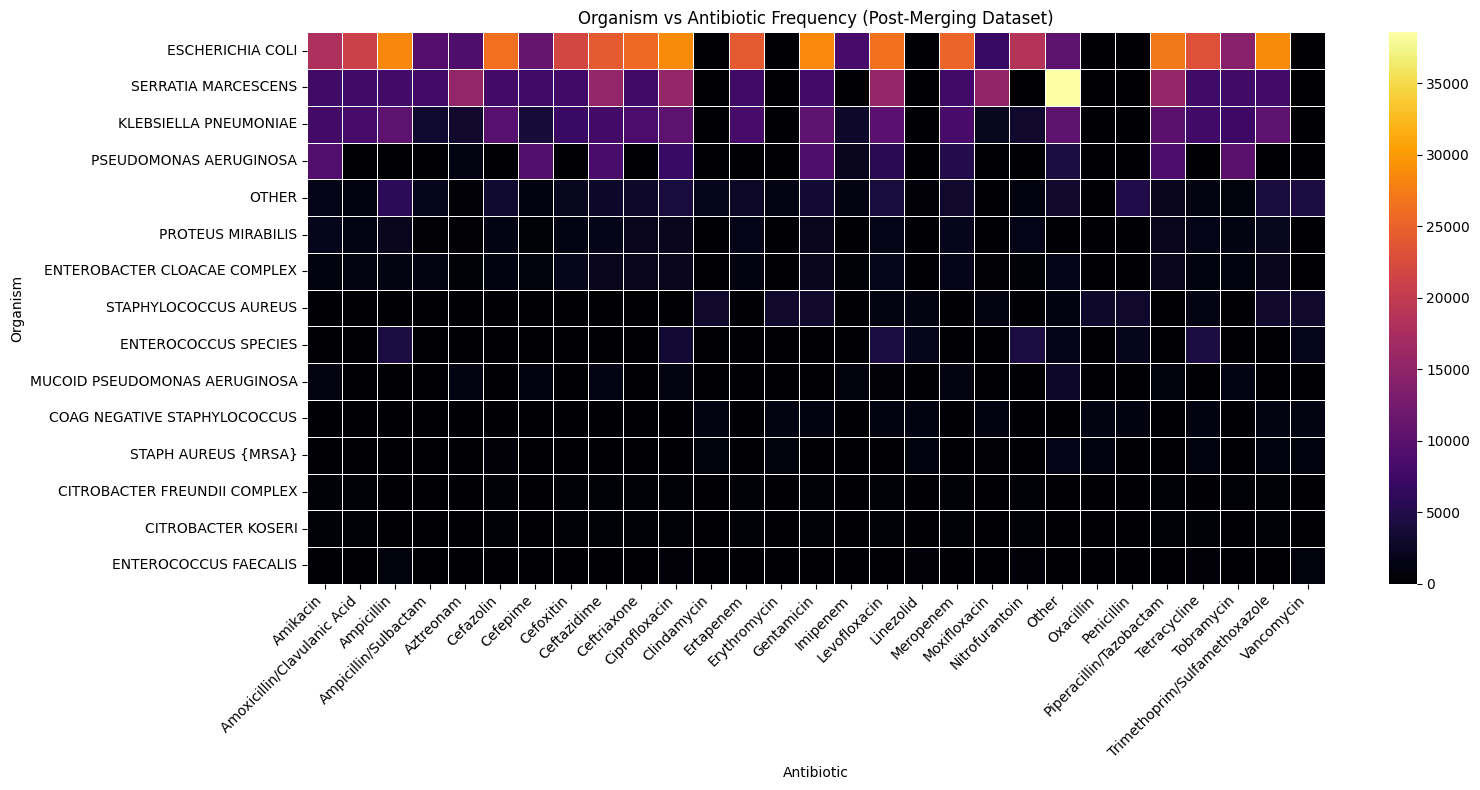

In [10]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_parquet("merged_sample_one_processed/final_stage/part.0.parquet")

# Create figure directory
fig_dir = "figs"
os.makedirs(fig_dir, exist_ok=True)

antibiotic_map = {
    21: "Other",
    10: "Ciprofloxacin",
    14: "Gentamicin",
    16: "Levofloxacin",
    27: "Trimethoprim/Sulfamethoxazole",
    2:  "Ampicillin",
    20: "Nitrofurantoin",
    24: "Piperacillin/Tazobactam",
    5:  "Cefazolin",
    9:  "Ceftriaxone",
    18: "Meropenem",
    8:  "Ceftazidime",
    25: "Tetracycline",
    0:  "Amikacin",
    1:  "Amoxicillin/Clavulanic Acid",
    26: "Tobramycin",
    12: "Ertapenem",
    7:  "Cefoxitin",
    6:  "Cefepime",
    28: "Vancomycin",
    23: "Penicillin",
    4:  "Aztreonam",
    3:  "Ampicillin/Sulbactam",
    11: "Clindamycin",
    13: "Erythromycin",
    17: "Linezolid",
    22: "Oxacillin",
    19: "Moxifloxacin",
    15: "Imipenem",
}

organism_map = {
    7:  "ESCHERICHIA COLI",
    12: "OTHER",
    9:  "KLEBSIELLA PNEUMONIAE",
    18: "STAPHYLOCOCCUS AUREUS",
    13: "PROTEUS MIRABILIS",
    6:  "ENTEROCOCCUS SPECIES",
    15: "PSEUDOMONAS AERUGINOSA",
    4:  "ENTEROBACTER CLOACAE COMPLEX",
    11: "MUCOID PSEUDOMONAS AERUGINOSA",
    3:  "COAG NEGATIVE STAPHYLOCOCCUS",
    0:  "ACHROMOBACTER XYLOSOXIDANS",
    17: "STAPH AUREUS {MRSA}",
    8:  "KLEBSIELLA OXYTOCA",
    19: "STREPTOCOCCUS AGALACTIAE (GROUP B)",
    2:  "CITROBACTER KOSERI",
    1:  "CITROBACTER FREUNDII COMPLEX",
    16: "SERRATIA MARCESCENS",
    14: "PROVIDENCIA RETTGERI",
    10: "MORGANELLA MORGANII",
    5:  "ENTEROCOCCUS FAECALIS",
    20: "ZZZENTEROBACTER AEROGENES",
}

df['antibiotic'] = df['antibiotic'].map(antibiotic_map)
df['organism'] = df['organism'].map(organism_map)   

# -------------------------
# 1) Create pivot table
# -------------------------
heatmap_data = pd.crosstab(df['organism'], df['antibiotic'])

print("Pivot table shape:", heatmap_data.shape)

# Optional: reduce to top N organisms for readability
top_n = 15
top_organisms = df['organism'].value_counts().head(top_n).index
heatmap_data = heatmap_data.loc[top_organisms]

# -------------------------
# 2) Plot Heatmap
# -------------------------
plt.figure(figsize=(16, 8))

sns.heatmap(heatmap_data, cmap="inferno", linewidths=0.5)

plt.title("Organism vs Antibiotic Frequency (Post-Merging Dataset)")
plt.xlabel("Antibiotic")
plt.ylabel("Organism")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

filename = "organism_antibiotic_heatmap_post_merging.png"
filepath = os.path.join(fig_dir, filename)

plt.savefig(filepath, dpi=300)
print(f"Heatmap saved: {filepath}")

plt.show()